In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rs = 1234

## E-Commerce Dataset
df_cc = pd.read_excel(r"E_Commerce_Dataset.xlsx", sheet_name='E_Comm')
df_cc.info()
df_cc.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [6]:
df_cc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [7]:
df_cc.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [ ]:
#combining all redundant double names as one name
df_cc.loc[(df_cc['PreferredPaymentMode']=='CC')|(df_cc['PreferredPaymentMode']=='Credit Card'),'PreferredPaymentMode']='Credit Card'
df_cc.loc[(df_cc['PreferredPaymentMode']=='COD')|(df_cc['PreferredPaymentMode']=='Cash on Delivery'),'PreferredPaymentMode']='Cash on Delivery'
df_cc.loc[(df_cc['PreferredPaymentMode']=='UPI')|(df_cc['PreferredPaymentMode']=='E wallet'),'PreferredPaymentMode']='Electronic Payment'

#combining phone and mobile phone as login device since you cannot log in on a home phone
df_cc.loc[(df_cc['PreferredLoginDevice']=='Mobile Phone')|(df_cc['PreferredLoginDevice']=='Phone'),'PreferredLoginDevice']='Phone'

#combining Mobile Phone and Mobile in the PreferredOrderCat column, since assumed they were the same thing
df_cc.loc[(df_cc['PreferedOrderCat']=='Mobile Phone')|(df_cc['PreferedOrderCat']=='Mobile'),'PreferedOrderCat']='Mobile Phone'

#fixing column name typo
df_cc = df_cc.rename(columns={'PreferedOrderCat':'PreferredOrderCat'})

c:\Users\Jeffrey Tolmachewich\.conda\envs\misy331_base\Lib\site-packages\numpy\lib\_histograms_impl.py:841: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\Jeffrey Tolmachewich\.conda\envs\misy331_base\Lib\site-packages\numpy\lib\_histograms_impl.py:842: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)
c:\Users\Jeffrey Tolmachewich\.conda\envs\misy331_base\Lib\site-packages\numpy\lib\_histograms_impl.py:841: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\Jeffrey Tolmachewich\.conda\envs\misy331_base\Lib\site-packages\numpy\lib\_histograms_impl.py:842: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)
c:\Users\Jeffrey Tolmachewich\.conda\envs\misy331_base\Lib\site-packages\numpy\lib\_histograms_impl.py:841: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\Jeffrey

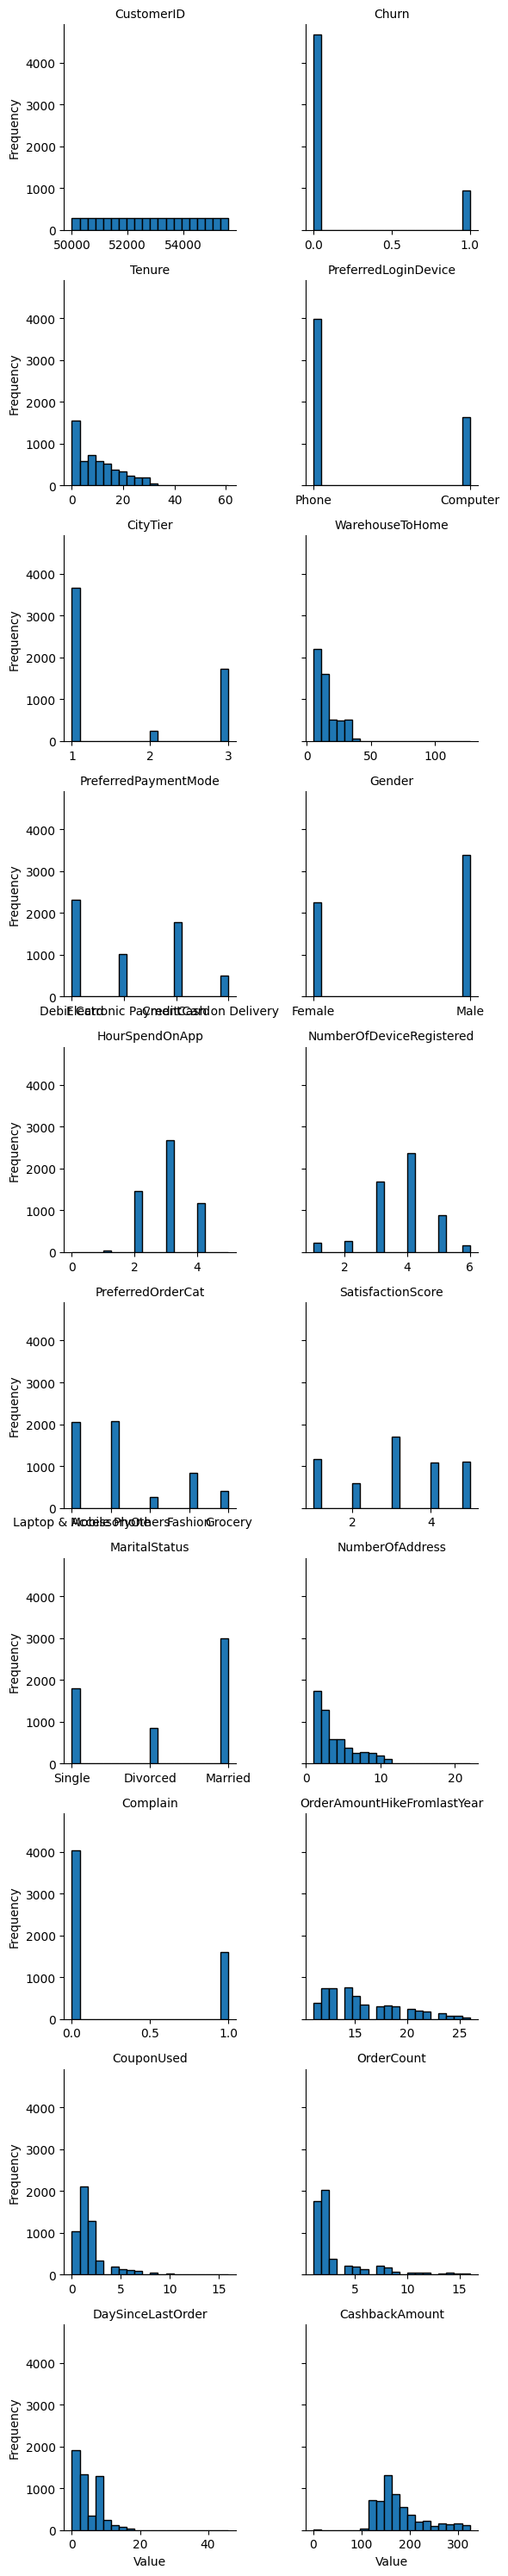

In [9]:
df_melted = df_cc.melt(var_name='variable', value_name='value')

# Create FacetGrid with histograms to see which variables have uneven distributions
g = sns.FacetGrid(df_melted, col='variable', col_wrap=2, height=3, sharex=False)
g.map(plt.hist, 'value', bins=20, edgecolor='black')
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Frequency")
plt.tight_layout()
plt.show()

In [10]:
# Remove high outliers while leaving NaNs
df_cc_clean = df_cc[(
                        ((df_cc['WarehouseToHome'] <= 100) | (df_cc['WarehouseToHome'].isna())) &
                        ((df_cc['DaySinceLastOrder'] <= 20) | (df_cc['DaySinceLastOrder'].isna())) &
                        ((df_cc['NumberOfAddress'] <= 15) | (df_cc['NumberOfAddress'].isna())) &
                        ((df_cc['Tenure'] <= 35) | (df_cc['Tenure'].isna()))
                       )].copy()

In [11]:
df_cc.shape

(5630, 20)

In [12]:
# we lose 13 observations doing that
df_cc_clean.shape

(5617, 20)

In [13]:
df_cc['CouponUsed'].value_counts().sort_index()

CouponUsed
0.0     1030
1.0     2105
2.0     1283
3.0      327
4.0      197
5.0      129
6.0      108
7.0       89
8.0       42
9.0       13
10.0      14
11.0      12
12.0       9
13.0       8
14.0       5
15.0       1
16.0       2
Name: count, dtype: int64

In [14]:
df_cc['OrderCount'].value_counts().sort_index()

OrderCount
1.0     1751
2.0     2025
3.0      371
4.0      204
5.0      181
6.0      137
7.0      206
8.0      172
9.0       62
10.0      36
11.0      51
12.0      54
13.0      30
14.0      36
15.0      33
16.0      23
Name: count, dtype: int64

In [15]:
# Because the minimum value of the OrderCount column is 1, we assume 
# that the missing values in those columns are people who didn't
# place an order in the last month, so we can fill the missing values with 0.
# We do the same with CouponUsed, since the logic is similar.

## Now fill in those columns' missing values with 0
df_cc_clean['CouponUsed'] = df_cc_clean['CouponUsed'].fillna(0)
df_cc_clean['OrderCount'] = df_cc_clean['OrderCount'].fillna(0)

# No lost observations, of course


In [16]:
df_cc_clean['HourSpendOnApp'].value_counts().sort_index()

HourSpendOnApp
0.0       3
1.0      35
2.0    1467
3.0    2681
4.0    1173
5.0       3
Name: count, dtype: int64

In [17]:
df_cc_clean['CouponUsed'].value_counts().sort_index()

CouponUsed
0.0     1284
1.0     2099
2.0     1279
3.0      327
4.0      197
5.0      128
6.0      108
7.0       89
8.0       42
9.0       13
10.0      14
11.0      12
12.0       9
13.0       8
14.0       5
15.0       1
16.0       2
Name: count, dtype: int64

In [18]:
df_cc_clean['OrderCount'].value_counts().sort_index()

OrderCount
0.0      258
1.0     1747
2.0     2019
3.0      369
4.0      204
5.0      181
6.0      137
7.0      206
8.0      172
9.0       62
10.0      36
11.0      50
12.0      54
13.0      30
14.0      36
15.0      33
16.0      23
Name: count, dtype: int64

In [19]:
df_cc_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5617 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5617 non-null   int64  
 1   Churn                        5617 non-null   int64  
 2   Tenure                       5354 non-null   float64
 3   PreferredLoginDevice         5617 non-null   object 
 4   CityTier                     5617 non-null   int64  
 5   WarehouseToHome              5366 non-null   float64
 6   PreferredPaymentMode         5617 non-null   object 
 7   Gender                       5617 non-null   object 
 8   HourSpendOnApp               5362 non-null   float64
 9   NumberOfDeviceRegistered     5617 non-null   int64  
 10  PreferredOrderCat            5617 non-null   object 
 11  SatisfactionScore            5617 non-null   int64  
 12  MaritalStatus                5617 non-null   object 
 13  NumberOfAddress        

Percentage of Missing Tenure by Category:
PreferredOrderCat
Mobile Phone          12.163462
Laptop & Accessory     0.536585
Fashion                0.000000
Grocery                0.000000
Others                 0.000000
Name: IsTenureMissing, dtype: float64


C:\Users\Jeffrey Tolmachewich\AppData\Local\Temp\ipykernel_35232\3382199741.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_stats.index, y=missing_stats.values, palette='Reds_r')


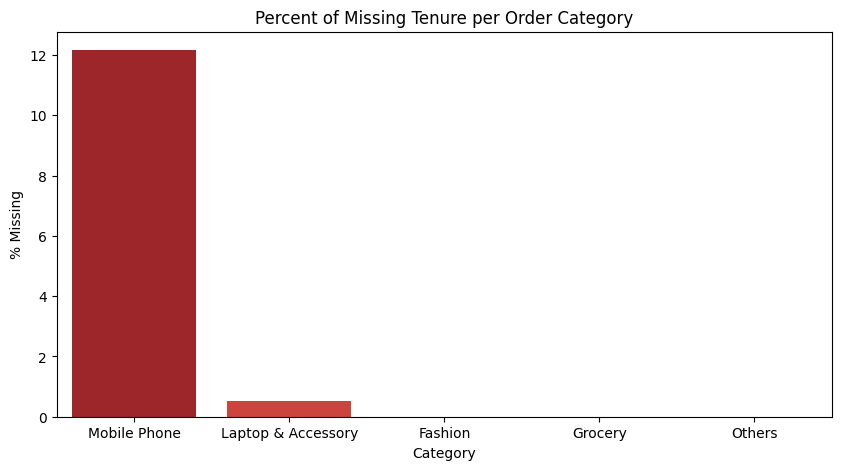

In [20]:
# Tenure is missing a lot of entries
df_cc['IsTenureMissing'] = df_cc['Tenure'].isna()

# Calculate the percentage of missing tenure for each order category
missing_stats = df_cc.groupby('PreferredOrderCat')['IsTenureMissing'].mean() * 100
missing_stats = missing_stats.sort_values(ascending=False)

print("Percentage of Missing Tenure by Category:")
print(missing_stats)

# Visualize the findings
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_stats.index, y=missing_stats.values, palette='Reds_r')
plt.title('Percent of Missing Tenure per Order Category')
plt.ylabel('% Missing')
plt.xlabel('Category')
plt.show()

In [21]:
# Almost all of the missing tenure values are in Mobile Phone
# This means that if we impute the median, we should make it the median for Mobile Phone
# In this case, 3
# Global median is 9, so that would be bad if we imputed that and skewed the data.
print(df_cc_clean.groupby('PreferredOrderCat')['Tenure'].median())

PreferredOrderCat
Fashion               11.0
Grocery               21.0
Laptop & Accessory     8.0
Mobile Phone           3.0
Others                20.0
Name: Tenure, dtype: float64


In [22]:
# Impute
df_cc_clean['Tenure'] = df_cc_clean['Tenure'].fillna(df_cc_clean.groupby('PreferredOrderCat')['Tenure'].transform('median'))

In [ ]:
# My theory is that the DaySinceLastOrder column's missing values are customers who just haven't ordered a second time.  
# Because they haven't ordered again, the OrderAmountHikeFromlastYear would probably be missing as well

missing_days = df_cc[df_cc['DaySinceLastOrder'].isna()]
total_missing_days = len(missing_days)

# Count how many of THESE rows also have missing 'OrderAmountHikeFromlastYear'
overlap = missing_days['OrderAmountHikeFromlastYear'].isna().sum()

print(f"Missing 'DaySinceLastOrder': {total_missing_days}")
print(f"Missing 'OrderAmountHikeFromlastYear': {overlap}")
print(f"Overlap Percentage: {(overlap / total_missing_days) * 100:.2f}%")
# Ok, so I was wrong

# So how many orders do these people have?
print("\nOrder Counts for customers with missing 'DaySinceLastOrder':")
print(missing_days['OrderCount'].value_counts(dropna=False))

# Seems to be a fairly wide distribution of all sorts of customers
# In this case, I'm comfortable imputing the mean here for DaySinceLastOrder

Missing 'DaySinceLastOrder': 307
Missing 'OrderAmountHikeFromlastYear': 0
Overlap Percentage: 0.00%

Order Counts for customers with missing 'DaySinceLastOrder':
OrderCount
2.0     122
1.0      35
3.0      22
8.0      20
4.0      20
5.0      15
6.0      13
9.0       9
7.0       8
11.0      8
14.0      8
12.0      6
16.0      6
10.0      6
13.0      5
15.0      4
Name: count, dtype: int64


In [24]:
# Impute
df_cc_clean['DaySinceLastOrder'] = df_cc_clean['DaySinceLastOrder'].fillna(df_cc_clean.groupby('OrderCount')['DaySinceLastOrder'].transform('median'))

Correlation between WarehouseToHome and Churn: 0.0766


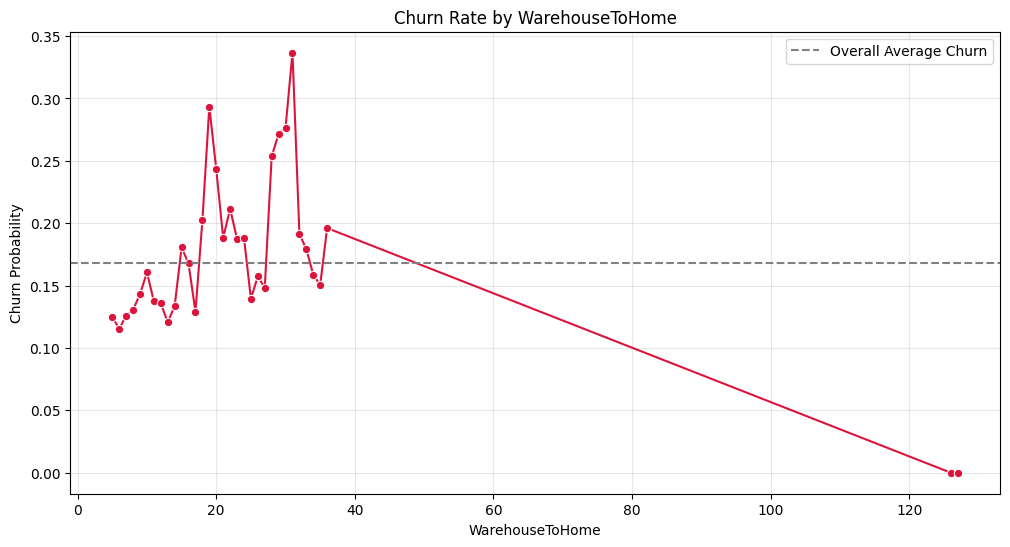

In [25]:
correlation = df_cc[['WarehouseToHome', 'Churn']].corr().iloc[0, 1]
print(f"Correlation between WarehouseToHome and Churn: {correlation:.4f}")

# Churn Rate by WarehouseToHome
# This shows the % of people who churned at each WarehouseToHome distance
churn_rate_by_distance = df_cc.groupby('WarehouseToHome')['Churn'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='WarehouseToHome', y='Churn', data=churn_rate_by_distance, marker='o', color='crimson')
plt.title('Churn Rate by WarehouseToHome')
plt.xlabel('WarehouseToHome')
plt.ylabel('Churn Probability')
plt.axhline(y=df_cc['Churn'].mean(), color='grey', linestyle='--', label='Overall Average Churn')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Correlation between HourSpendOnApp and Churn: 0.0187


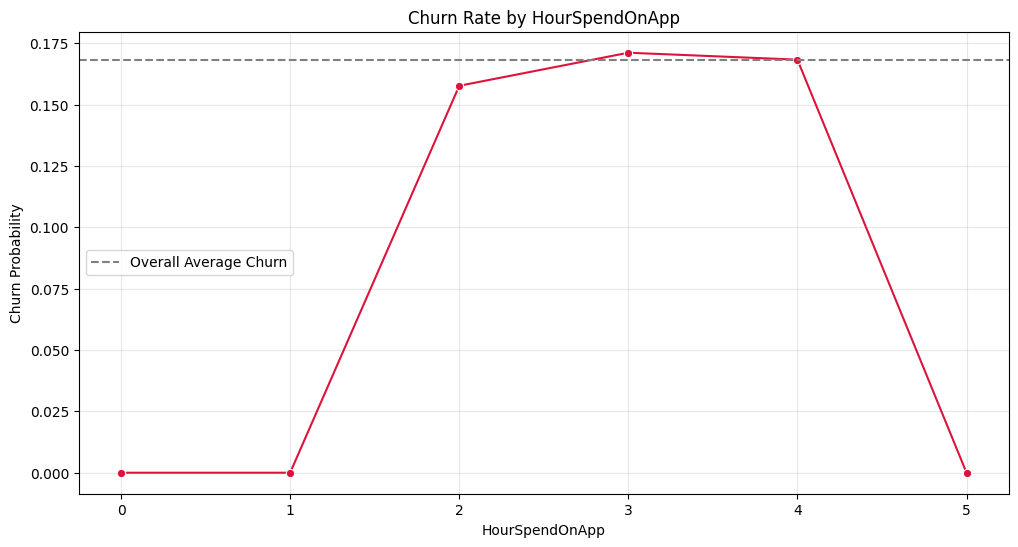

In [26]:
correlation = df_cc[['HourSpendOnApp', 'Churn']].corr().iloc[0, 1]
print(f"Correlation between HourSpendOnApp and Churn: {correlation:.4f}")

# Churn Rate by HourSpendOnApp
# % of people who churned at each hour amount
churn_rate_by_distance = df_cc.groupby('HourSpendOnApp')['Churn'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='HourSpendOnApp', y='Churn', data=churn_rate_by_distance, marker='o', color='crimson')
plt.title('Churn Rate by HourSpendOnApp')
plt.xlabel('HourSpendOnApp')
plt.ylabel('Churn Probability')
plt.axhline(y=df_cc['Churn'].mean(), color='grey', linestyle='--', label='Overall Average Churn')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Correlation between OrderAmountHikeFromlastYear and Churn: -0.0101


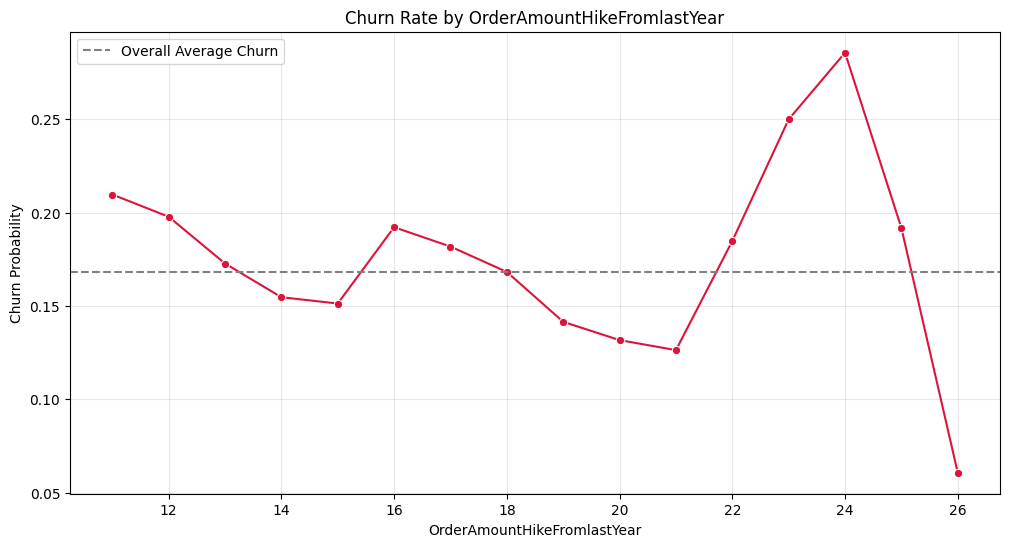

In [27]:
correlation = df_cc[['OrderAmountHikeFromlastYear', 'Churn']].corr().iloc[0, 1]
print(f"Correlation between OrderAmountHikeFromlastYear and Churn: {correlation:.4f}")

# Churn Rate by OrderAmountHikeFromlastYear
# % of people who churned at each OrderAmountHikeFromlastYear amount
churn_rate_by_distance = df_cc.groupby('OrderAmountHikeFromlastYear')['Churn'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='OrderAmountHikeFromlastYear', y='Churn', data=churn_rate_by_distance, marker='o', color='crimson')
plt.title('Churn Rate by OrderAmountHikeFromlastYear')
plt.xlabel('OrderAmountHikeFromlastYear')
plt.ylabel('Churn Probability')
plt.axhline(y=df_cc['Churn'].mean(), color='grey', linestyle='--', label='Overall Average Churn')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# Overall, these 3 plots show that the remaining variables with missing values aren't highly correlated with churn at all
# So we can fill these in in the same way: based on the median values
fill_values = {
    'OrderAmountHikeFromlastYear': df_cc_clean['OrderAmountHikeFromlastYear'].median(),
    'HourSpendOnApp': df_cc_clean['HourSpendOnApp'].median(),
    'WarehouseToHome': df_cc_clean['WarehouseToHome'].median(),
}

# Impute
df_cc_clean = df_cc_clean.fillna(value=fill_values)

In [29]:
df_cc_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5617 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5617 non-null   int64  
 1   Churn                        5617 non-null   int64  
 2   Tenure                       5617 non-null   float64
 3   PreferredLoginDevice         5617 non-null   object 
 4   CityTier                     5617 non-null   int64  
 5   WarehouseToHome              5617 non-null   float64
 6   PreferredPaymentMode         5617 non-null   object 
 7   Gender                       5617 non-null   object 
 8   HourSpendOnApp               5617 non-null   float64
 9   NumberOfDeviceRegistered     5617 non-null   int64  
 10  PreferredOrderCat            5617 non-null   object 
 11  SatisfactionScore            5617 non-null   int64  
 12  MaritalStatus                5617 non-null   object 
 13  NumberOfAddress        

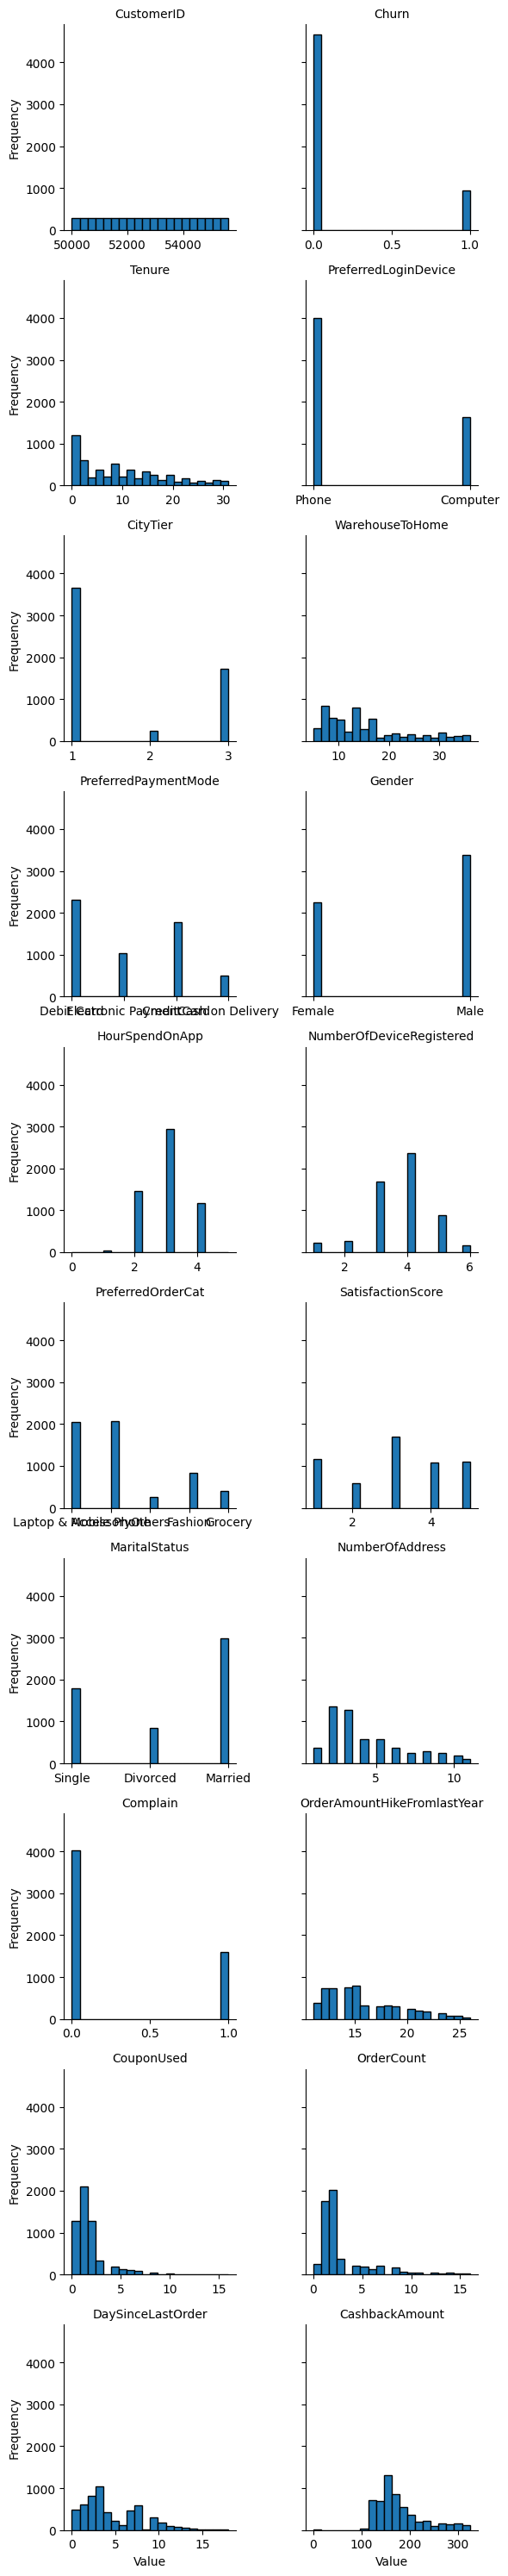

In [30]:
df_melted = df_cc_clean.melt(var_name='variable', value_name='value')

# Create FacetGrid with histograms to show our finished product
g = sns.FacetGrid(df_melted, col='variable', col_wrap=2, height=3, sharex=False)
g.map(plt.hist, 'value', bins=20, edgecolor='black')
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Frequency")
plt.tight_layout()
plt.show()

In [31]:
# Now we have to change everything to the right data type
float_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']

df_cc_clean[float_cols] = df_cc_clean[float_cols].astype(int)

In [32]:
df_cc_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5617 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5617 non-null   int64  
 1   Churn                        5617 non-null   int64  
 2   Tenure                       5617 non-null   int64  
 3   PreferredLoginDevice         5617 non-null   object 
 4   CityTier                     5617 non-null   int64  
 5   WarehouseToHome              5617 non-null   int64  
 6   PreferredPaymentMode         5617 non-null   object 
 7   Gender                       5617 non-null   object 
 8   HourSpendOnApp               5617 non-null   int64  
 9   NumberOfDeviceRegistered     5617 non-null   int64  
 10  PreferredOrderCat            5617 non-null   object 
 11  SatisfactionScore            5617 non-null   int64  
 12  MaritalStatus                5617 non-null   object 
 13  NumberOfAddress        

In [33]:
# create dummy variables
cols_to_dummify = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferredOrderCat', 'MaritalStatus']
df_cleaned = pd.get_dummies(df_cc_clean, columns=cols_to_dummify, drop_first=True, dtype = int)

In [34]:
from sklearn.model_selection import train_test_split
# Drop dependent variable and split
exclude = ['CustomerID']

dep_var = 'Churn'
X = df_cleaned.drop(columns = exclude).dropna()

y = X[dep_var]
X1 = X.drop(dep_var, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X1,
                                                    y, 
                                                    test_size = 0.2,
                                                    stratify = y,
                                                    random_state=rs)

In [35]:
X1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5617 entries, 0 to 5629
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Tenure                                   5617 non-null   int64  
 1   CityTier                                 5617 non-null   int64  
 2   WarehouseToHome                          5617 non-null   int64  
 3   HourSpendOnApp                           5617 non-null   int64  
 4   NumberOfDeviceRegistered                 5617 non-null   int64  
 5   SatisfactionScore                        5617 non-null   int64  
 6   NumberOfAddress                          5617 non-null   int64  
 7   Complain                                 5617 non-null   int64  
 8   OrderAmountHikeFromlastYear              5617 non-null   int64  
 9   CouponUsed                               5617 non-null   int64  
 10  OrderCount                               5617 non-nul

In [36]:
import pickle as pk
with open("df_cleaned.pkl", 'wb') as file:
    pk.dump(df_cc_clean, file)

In [37]:
with open("X_train.pkl", 'wb') as file:
    pk.dump(X_train, file)

In [38]:
with open("X_test.pkl", 'wb') as file:
    pk.dump(X_test, file)

In [39]:
with open("y_train.pkl", 'wb') as file:
    pk.dump(y_train, file)

In [40]:
with open("y_test.pkl", 'wb') as file:
    pk.dump(y_test, file)